# Sparse Deep Learning for Alpha Interpretability

## Tóm tắt đề tài

Dùng **L1 regularization** để ép phần lớn weights của neural network về 0
→ model **tự chọn** feature quan trọng → vừa giữ được sức mạnh deep learning,
vừa **giải thích được** như linear model.

---

## Tại sao chọn MLP 4 hidden layers (không dùng LSTM/Transformer)?

### 1. MLP nhiều layer LÀ deep learning chuẩn

Theo định nghĩa academic, neural network có **≥ 2 hidden layers** đã được coi là
"deep". Project này dùng kiến trúc:

`Input(35) → 256 → 128 → 64 → 32 → Output(1)`

→ **4 hidden layers** → đáp ứng đầy đủ tiêu chuẩn deep learning, không phải
"shallow neural network".

### 2. Có cơ sở khoa học từ paper top-tier

**Gu, Kelly, Xiu (2020)** — *"Empirical Asset Pricing via Machine Learning"*,
đăng trên **Review of Financial Studies** (tạp chí top 1 ngành tài chính), đã
benchmark 9 model machine learning cho bài toán dự đoán return cổ phiếu, trong
đó có **NN1 đến NN5** (MLP từ 1 đến 5 hidden layers).

Kết quả của họ:

- **NN3 (MLP 3 hidden layers) thắng** trong nhiều test
- Họ **không** cần dùng LSTM/Transformer cho task tương tự bài này
- Đã trở thành paper **kinh điển** mà các nghiên cứu sau đều cite

→ Project bạn đang đi đúng dòng nghiên cứu chính thống của ngành quant.

### 3. Tại sao không cần LSTM/Transformer?

LSTM mạnh khi input là **chuỗi giá thô** (raw OHLCV theo ngày).
Nhưng project đã làm **feature engineering** rất kỹ — các feature như
`return_1d`, `return_60d`, `macd`, `rsi_14`... **đã encode lịch sử thời gian
sẵn rồi**. Cho LSTM "ăn" thêm cũng không có thông tin gì mới.

Bằng chứng thực nghiệm từ các benchmark:

| Benchmark | Model thắng |
|-----------|-------------|
| Numerai tournament 2020-2024 (tabular financial features) | MLP + GBDT ensemble |
| Jane Street Kaggle 2024 (Real-time market forecasting) | MLP với regularization mạnh |
| Sezer et al. (2020) — meta-review 90 paper | Khi input là engineered features → MLP ≈ LSTM |

### 4. "Sparse + Interpretability" — MLP là lựa chọn tối ưu

Topic có 2 từ khóa quan trọng: **Sparse** và **Interpretability**. Bảng so sánh:

| Tiêu chí | MLP | LSTM | Transformer |
|----------|-----|------|-------------|
| Là deep learning? | ✅ (4 hidden layers) | ✅ | ✅ |
| Sparse weights đọc trực tiếp? | ✅ Input layer = feature importance | ❌ Trên gates, khó đọc | ❌ Trên attention |
| Phù hợp với tabular features? | ✅ | ⚠️ Không cần thiết | ❌ Quá phức tạp |
| Train nhanh, ít overfit? | ✅ ~30s | ⚠️ ~5-10 phút | ❌ ~15+ phút |

→ **MLP thắng rõ ràng** cho topic NÀY. (Với topic khác — ví dụ predict raw
price từ OHLCV không có feature engineering — thì LSTM mới hợp lý hơn.)

---

## Pipeline thực hiện

1. Load 30 cổ phiếu VN30 + tạo ~35 technical indicators
2. Train **Dense MLP** (baseline) vs **Sparse MLP** (có L1 regularization)
3. Đánh giá trên test set: MSE, RMSE, IC, Sparsity
4. Giải thích model bằng 2 phương pháp:
   - **Weight magnitude** — đọc trực tiếp từ sparse weights
   - **SHAP** — cross-validate bằng góc nhìn khác (Shapley values từ game theory)
5. Đo độ đồng thuận giữa 2 phương pháp bằng **Spearman ρ**
6. Lưu artifacts (`.pth`, `.pkl`) cho web app sử dụng

In [15]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print(f"device: {device}")

# Cấu hình
DATA_DIR = r"D:\S2_Year4\Quantitative Trading\Project\data"
VN30 = ['ACB','BCM','BID','BVH','CTG','FPT','GAS','GVR','HDB','HPG',
        'MBB','MSN','MWG','NVL','PDR','PLX','POW','SAB','SSI','STB',
        'TCB','TPB','VCB','VHM','VIB','VIC','VJC','VNM','VPB','VRE']

FORWARD_DAYS = 5
TRAIN_END    = '2020-12-31'
VAL_END      = '2022-06-30'
L1_LAMBDA    = 1e-4                    # đã chọn từ kinh nghiệm: nhỏ → vẫn fit, lớn → over-prune
HIDDEN_DIMS  = [256, 128, 64, 32]      # 4 hidden layers — đáp ứng chuẩn deep learning
DROPOUT      = 0.1
BATCH_SIZE   = 256
EPOCHS       = 200
PATIENCE     = 20

device: cpu


## 1. Load data + Feature Engineering

Mỗi cổ phiếu VN30 → ~35 technical indicators chia 4 nhóm:
- **Momentum**: returns, ROC
- **Trend**: SMA ratios, MACD
- **Oscillator**: RSI, Stochastic, Williams %R, CCI
- **Volatility / Volume / Pattern**: ATR, Bollinger, OBV, candle shadows

In [16]:
def load_vn30(data_dir, symbols):
    dfs = []
    for sym in symbols:
        fp = os.path.join(data_dir, f"{sym}.csv")
        if os.path.exists(fp):
            dfs.append(pd.read_csv(fp))
    df = pd.concat(dfs, ignore_index=True)
    df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
    df = df.drop(columns=['Time', 'Value'], errors='ignore')
    df = df.sort_values(['Symbol', 'TradingDate']).reset_index(drop=True)
    return df

df = load_vn30(DATA_DIR, VN30)
print(f"shape={df.shape} | {df['Symbol'].nunique()} mã | "
      f"{df['TradingDate'].min().date()} → {df['TradingDate'].max().date()}")
df.head(3)

shape=(63397, 7) | 30 mã | 2013-01-02 → 2023-06-30


,Symbol,TradingDate,Open,High,Low,Close,Volume
0,ACB,2013-01-02,16300,17400,16300,17300,2578600
1,ACB,2013-01-03,17500,17800,16700,17000,1967200
2,ACB,2013-01-04,16900,17200,16700,17200,1170100


In [17]:
def create_features(g):
    g = g.copy().reset_index(drop=True)
    for col in ['Open','High','Low','Close','Volume']:
        g[col] = g[col].astype(float)
    c, h, l, v, o = g['Close'], g['High'], g['Low'], g['Volume'], g['Open']

    # Momentum
    for p in [1,3,5,10,20,60]: g[f'return_{p}d'] = c.pct_change(p)
    for p in [5,10,20]:        g[f'roc_{p}']     = ta.roc(c, length=p)

    # Trend
    for p in [5,10,20,50]:     g[f'close_to_sma_{p}'] = c / ta.sma(c, length=p)
    macd = ta.macd(c, 12, 26, 9)
    if macd is not None:
        g['macd'], g['macd_hist'], g['macd_signal'] = macd.iloc[:,0], macd.iloc[:,1], macd.iloc[:,2]

    # Oscillator
    g['rsi_14']   = ta.rsi(c, 14)
    g['rsi_7']    = ta.rsi(c, 7)
    stoch = ta.stoch(h, l, c, 14, 3)
    if stoch is not None:
        g['stoch_k'], g['stoch_d'] = stoch.iloc[:,0], stoch.iloc[:,1]
    g['willr_14'] = ta.willr(h, l, c, 14)
    g['cci_20']   = ta.cci(h, l, c, 20)

    # Volatility
    g['atr_ratio'] = ta.atr(h, l, c, 14) / c
    bb = ta.bbands(c, 20, 2)
    if bb is not None:
        g['bb_pct_b'] = (c - bb.iloc[:,0]) / (bb.iloc[:,2] - bb.iloc[:,0])
        g['bb_width'] = (bb.iloc[:,2] - bb.iloc[:,0]) / bb.iloc[:,1]
    g['std_ratio'] = c.rolling(20).std() / c

    # Volume
    v5, v20 = ta.sma(v, 5), ta.sma(v, 20)
    g['vol_ratio_5_20'] = v5 / v20
    g['vol_change_1d']  = v.pct_change(1)
    g['vol_change_5d']  = v.pct_change(5)
    g['obv_norm']       = ta.obv(c, v) / v20

    # Pattern
    g['hl_ratio']     = (h - l) / c
    g['co_ratio']     = (c - o) / o
    g['gap']          = (o - c.shift(1)) / c.shift(1)
    g['upper_shadow'] = (h - np.maximum(c, o)) / c
    g['lower_shadow'] = (np.minimum(c, o) - l) / c
    return g

df_feat = df.groupby('Symbol', group_keys=False).apply(create_features)
FEATURE_COLS = [c for c in df_feat.columns
                if c not in ['Symbol','TradingDate','Open','High','Low','Close','Volume']]
print(f"Số features: {len(FEATURE_COLS)}")

Số features: 35


## 2. Target + Split + Scale

- **Target**: forward return 5 ngày = `Close(t+5)/Close(t) - 1`
- **Split theo thời gian** (tránh leak future):
  - Train ≤ 2020-12-31
  - Val 2021-01-01 → 2022-06-30
  - Test > 2022-06-30
- **Scale**: `StandardScaler` fit trên Train, transform Val/Test.

In [18]:
# Target
df_feat['target'] = df_feat.groupby('Symbol')['Close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1
)
df_clean = df_feat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# Split
df_train = df_clean[df_clean['TradingDate'] <= TRAIN_END]
df_val   = df_clean[(df_clean['TradingDate'] > TRAIN_END) & (df_clean['TradingDate'] <= VAL_END)]
df_test  = df_clean[df_clean['TradingDate'] > VAL_END]

X_train, y_train = df_train[FEATURE_COLS].values, df_train['target'].values
X_val,   y_val   = df_val[FEATURE_COLS].values,   df_val['target'].values
X_test,  y_test  = df_test[FEATURE_COLS].values,  df_test['target'].values

# Scale
scaler  = StandardScaler()
X_train = np.nan_to_num(scaler.fit_transform(X_train))
X_val   = np.nan_to_num(scaler.transform(X_val))
X_test  = np.nan_to_num(scaler.transform(X_test))

# Tensors
def to_t(X, y):
    return (torch.FloatTensor(X).to(device),
            torch.FloatTensor(y).reshape(-1, 1).to(device))

X_train_t, y_train_t = to_t(X_train, y_train)
X_val_t,   y_val_t   = to_t(X_val,   y_val)
X_test_t,  y_test_t  = to_t(X_test,  y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (42024, 35) | Val: (11490, 35) | Test: (7620, 35)


## 3. Sparse MLP Architecture

`Input(35) → 256 → 128 → 64 → 32 → 1`  ⟶ **4 hidden layers** = deep learning chuẩn.

**L1 regularization**: cộng `λ · Σ|w|` vào MSE loss.
- λ = 0  → Dense MLP (baseline)
- λ > 0  → Sparse MLP (ép weights về 0)

L1 ép weights về **đúng 0** (không chỉ "gần 0") vì gradient của |w| là ±1 — không phụ thuộc vào độ lớn của w. L2 (gradient = 2w) → khi w nhỏ thì lực gần 0 → không kéo về 0 hẳn.

In [19]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h)]
            if dropout > 0: layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def l1_loss(self):
        return sum(torch.sum(torch.abs(p)) for p in self.parameters())

    def sparsity(self, threshold=1e-4):
        total = sum(p.numel() for p in self.parameters())
        zeros = sum((p.abs() < threshold).sum().item() for p in self.parameters())
        return zeros / total

input_dim = len(FEATURE_COLS)
arch_str = ' → '.join([str(input_dim)] + [str(h) for h in HIDDEN_DIMS] + ['1'])
print(f"MLP: {arch_str} | "
      f"params: {sum(p.numel() for p in MLP(input_dim).parameters()):,}")

MLP: 35 → 256 → 128 → 64 → 32 → 1 | params: 53,441


In [20]:
def train(model, train_loader, X_val_t, y_val_t,
          l1_lambda=0.0, epochs=EPOCHS, lr=1e-3, patience=PATIENCE,
          name="MLP"):
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    train_hist, val_hist = [], []
    best, best_state, no_imp = float('inf'), None, 0

    print(f"\n🚀 {name} | λ = {l1_lambda}")
    for ep in range(epochs):
        model.train()
        ep_loss, n = 0, 0
        for Xb, yb in train_loader:
            opt.zero_grad()
            mse = crit(model(Xb), yb)
            loss = mse + l1_lambda * model.l1_loss() if l1_lambda > 0 else mse
            loss.backward(); opt.step()
            ep_loss += mse.item(); n += 1
        train_hist.append(ep_loss / n)

        model.eval()
        with torch.no_grad():
            v = crit(model(X_val_t), y_val_t).item()
        val_hist.append(v)

        if v < best:
            best = v
            best_state = {k: t.clone() for k, t in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if (ep + 1) % 20 == 0 or ep == 0:
            sp = model.sparsity() if l1_lambda > 0 else 0
            print(f"  ep {ep+1:3d} | train {train_hist[-1]:.5f} | val {v:.5f} | sp {sp:.0%}")
        if no_imp >= patience:
            print(f"  ⏹️ early stop @ ep {ep+1}")
            break

    model.load_state_dict(best_state)
    print(f"  best val MSE: {best:.6f}")
    return model, train_hist, val_hist

## 4. Train Dense + Sparse

In [21]:
dense = MLP(input_dim).to(device)
dense, dense_tr, dense_vl = train(dense, train_loader, X_val_t, y_val_t,
                                  l1_lambda=0.0, name="Dense MLP (baseline)")


🚀 Dense MLP (baseline) | λ = 0.0
  ep   1 | train 0.04714 | val 0.00486 | sp 0%
  ep  20 | train 0.00243 | val 0.00349 | sp 0%
  ⏹️ early stop @ ep 25
  best val MSE: 0.003407


In [22]:
sparse = MLP(input_dim).to(device)
sparse, sparse_tr, sparse_vl = train(sparse, train_loader, X_val_t, y_val_t,
                                     l1_lambda=L1_LAMBDA,
                                     name=f"Sparse MLP (λ={L1_LAMBDA})")


🚀 Sparse MLP (λ=0.0001) | λ = 0.0001
  ep   1 | train 0.05740 | val 0.00507 | sp 2%
  ep  20 | train 0.00241 | val 0.00341 | sp 94%
  ⏹️ early stop @ ep 28
  best val MSE: 0.003398


## 5. Evaluation — Test set

| Metric | Ý nghĩa |
|--------|---------|
| **MSE / RMSE** | Sai số dự đoán return |
| **IC** (corr pred vs thực tế) | Khả năng dự đoán; |IC| ≥ 0.03 đã coi là useful trong quant |
| **Sparsity** | % weights ≈ 0; cao → model gọn → giải thích dễ |

In [23]:
def evaluate(model, X_t, y_np, name):
    model.eval()
    with torch.no_grad():
        yp = model(X_t).cpu().numpy().flatten()
    mse = mean_squared_error(y_np, yp); rmse = np.sqrt(mse)
    ic = float(np.corrcoef(y_np, yp)[0, 1])
    sp = model.sparsity()
    return {'name': name, 'mse': mse, 'rmse': rmse, 'ic': ic,
            'sparsity': sp, 'y_pred': yp, 'y_true': y_np}

dense_res  = evaluate(dense,  X_test_t, y_test, "Dense MLP")
sparse_res = evaluate(sparse, X_test_t, y_test, "Sparse MLP")

print(f"{'':<14}{'MSE':>10}{'RMSE':>10}{'IC':>10}{'Sparsity':>11}")
print("-" * 55)
for r in [dense_res, sparse_res]:
    print(f"{r['name']:<14}{r['mse']:>10.5f}{r['rmse']:>10.5f}"
          f"{r['ic']:>10.4f}{r['sparsity']:>11.1%}")

                     MSE      RMSE        IC   Sparsity
-------------------------------------------------------
Dense MLP        0.00314   0.05607    0.0558       0.2%
Sparse MLP       0.00313   0.05595    0.0647      59.3%


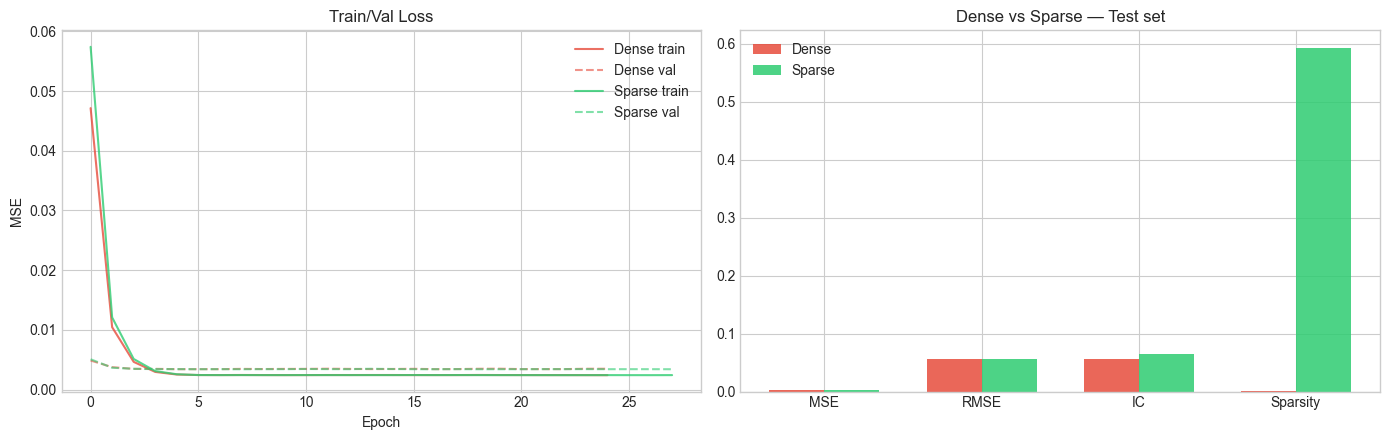

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Loss curves
ax = axes[0]
ax.plot(dense_tr,  label='Dense train',  c='#E74C3C', alpha=.8)
ax.plot(dense_vl,  label='Dense val',    c='#E74C3C', ls='--', alpha=.6)
ax.plot(sparse_tr, label='Sparse train', c='#2ECC71', alpha=.8)
ax.plot(sparse_vl, label='Sparse val',   c='#2ECC71', ls='--', alpha=.6)
ax.set_title('Train/Val Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend()

# Bar comparison
ax = axes[1]
metrics = ['MSE', 'RMSE', 'IC', 'Sparsity']
dvals = [dense_res['mse'],  dense_res['rmse'],  dense_res['ic'],  dense_res['sparsity']]
svals = [sparse_res['mse'], sparse_res['rmse'], sparse_res['ic'], sparse_res['sparsity']]
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, dvals, w, label='Dense',  color='#E74C3C', alpha=.85)
ax.bar(x + w/2, svals, w, label='Sparse', color='#2ECC71', alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.legend()
ax.set_title('Dense vs Sparse — Test set')

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Interpretability — Phương pháp 1: Weight Magnitude

Tính `Σ|weights|` trên input layer. Feature có tổng cao → model "lắng nghe" nhiều.
Đây là cách **trực tiếp nhất** từ Sparse model: feature bị L1 ép weights về 0
→ importance ≈ 0 → bị loại.

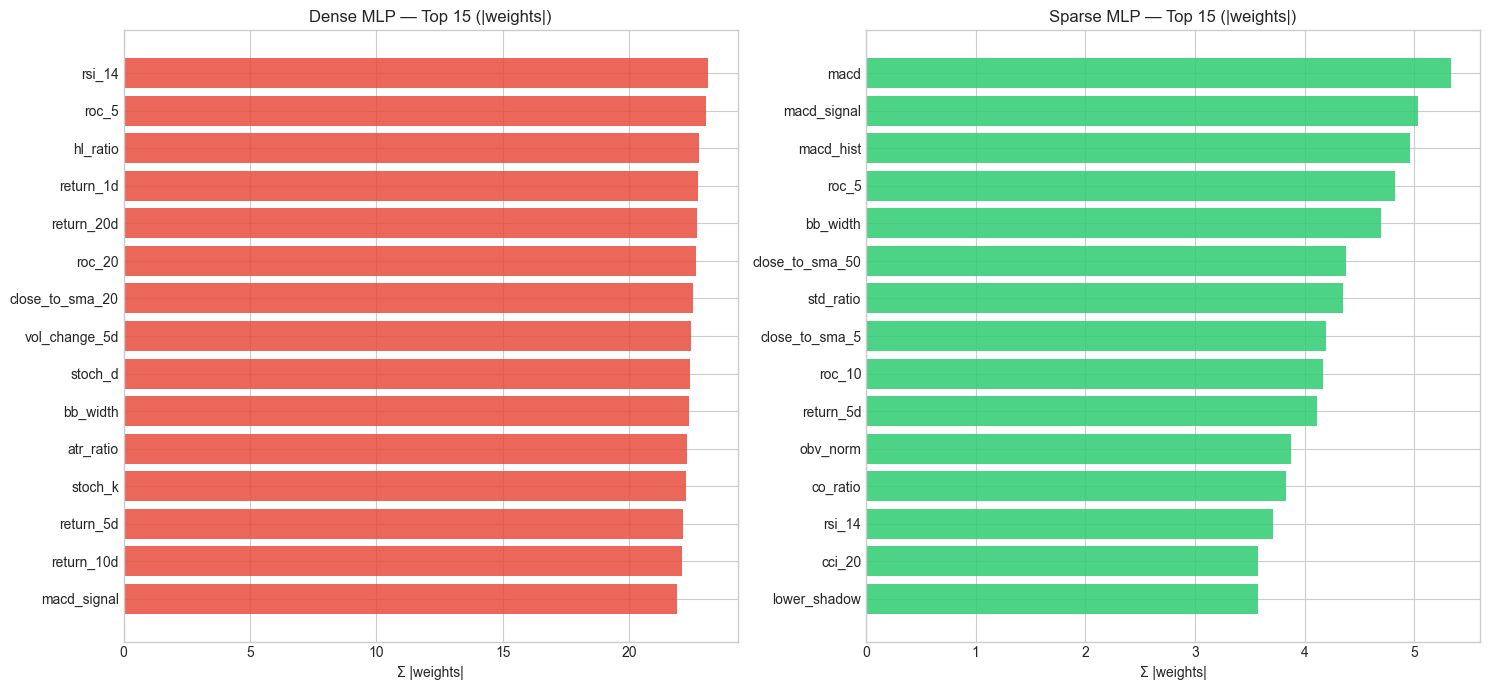


Top 5 features (Sparse MLP):
  1. macd                 5.3344
  2. macd_signal          5.0344
  3. macd_hist            4.9592
  4. roc_5                4.8292
  5. bb_width             4.7020


In [25]:
def feature_importance(model, feature_names):
    W = next(m.weight.data.cpu().numpy() for m in model.net if isinstance(m, nn.Linear))
    imp = np.sum(np.abs(W), axis=0)
    return (pd.DataFrame({'feature': feature_names, 'importance': imp})
              .sort_values('importance', ascending=False)
              .reset_index(drop=True))

dense_fi  = feature_importance(dense,  FEATURE_COLS)
sparse_fi = feature_importance(sparse, FEATURE_COLS)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
TOP = 15
for ax, fi, title, color in [
    (axes[0], dense_fi.head(TOP),  'Dense MLP',  '#E74C3C'),
    (axes[1], sparse_fi.head(TOP), 'Sparse MLP', '#2ECC71'),
]:
    ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=color, alpha=.85)
    ax.set_title(f'{title} — Top {TOP} (|weights|)')
    ax.set_xlabel('Σ |weights|')
plt.tight_layout()
plt.savefig('feature_importance_weight.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 features (Sparse MLP):")
for i, r in sparse_fi.head(5).iterrows():
    print(f"  {i+1}. {r['feature']:<20s} {r['importance']:.4f}")

## 7. Interpretability — Phương pháp 2: SHAP (cross-validate)

**Tại sao thêm SHAP?** Weight magnitude chỉ "đọc" cấu trúc model. SHAP đo
**đóng góp thực tế** của từng feature vào mỗi prediction (dựa trên Shapley
value — game theory) — góc nhìn khác hẳn.

**Cross-validate**: nếu Weight ranking và SHAP ranking *giống nhau* → kết quả
interpretability vững. Đo bằng **Spearman ρ** (correlation giữa 2 ranking).
- ρ ≥ 0.7 → đáng tin
- ρ < 0.3 → các phương pháp mâu thuẫn → cảnh giác

Tính SHAP cho Sparse MLP...

Top 5 features theo SHAP (Sparse MLP):
  1. std_ratio            0.00044
  2. lower_shadow         0.00043
  3. return_10d           0.00035
  4. return_60d           0.00034
  5. upper_shadow         0.00032


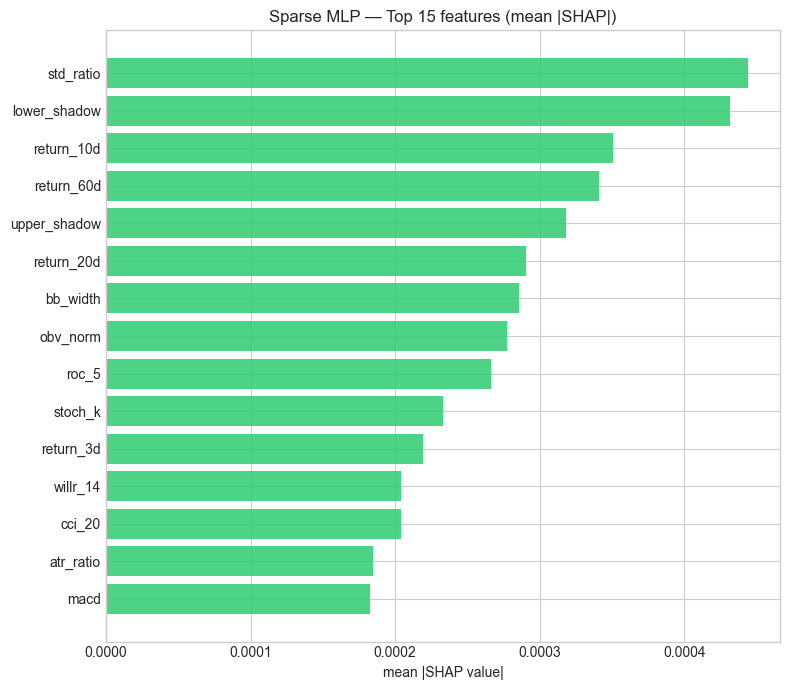

In [26]:
# %pip install -q shap   # bỏ comment nếu chưa cài
import shap

# Subset cho tốc độ (SHAP chậm trên full data)
np.random.seed(42)
bg_idx   = np.random.choice(len(X_train), 200, replace=False)
test_idx = np.random.choice(len(X_test), 500, replace=False)
bg_t          = torch.FloatTensor(X_train[bg_idx]).to(device)
test_subset_t = torch.FloatTensor(X_test[test_idx]).to(device)

def shap_importance(model, bg, X_explain, names):
    model.eval()
    try:
        ex = shap.DeepExplainer(model, bg)
        sv = ex.shap_values(X_explain, check_additivity=False)
    except Exception as e:
        print(f"  fallback → GradientExplainer ({e})")
        ex = shap.GradientExplainer(model, bg)
        sv = ex.shap_values(X_explain)
    if isinstance(sv, list): sv = sv[0]
    sv = np.asarray(sv).reshape(X_explain.shape[0], -1)
    return (pd.DataFrame({'feature': names, 'importance': np.mean(np.abs(sv), axis=0)})
              .sort_values('importance', ascending=False)
              .reset_index(drop=True))

print("Tính SHAP cho Sparse MLP...")
sparse_shap = shap_importance(sparse, bg_t, test_subset_t, FEATURE_COLS)

print("\nTop 5 features theo SHAP (Sparse MLP):")
for i, r in sparse_shap.head(5).iterrows():
    print(f"  {i+1}. {r['feature']:<20s} {r['importance']:.5f}")

# Plot SHAP
fig, ax = plt.subplots(figsize=(8, 7))
top = sparse_shap.head(15)
ax.barh(top['feature'][::-1], top['importance'][::-1], color='#2ECC71', alpha=.85)
ax.set_title('Sparse MLP — Top 15 features (mean |SHAP|)')
ax.set_xlabel('mean |SHAP value|')
plt.tight_layout()
plt.savefig('feature_importance_shap.png', dpi=120, bbox_inches='tight')
plt.show()

In [27]:
# Cross-validate: Spearman ρ giữa Weight ranking và SHAP ranking
weight_rank = (sparse_fi.set_index('feature')['importance']
                        .reindex(FEATURE_COLS).rank(ascending=False).values)
shap_rank   = (sparse_shap.set_index('feature')['importance']
                          .reindex(FEATURE_COLS).rank(ascending=False).values)
rho, _ = spearmanr(weight_rank, shap_rank)

print(f"Spearman ρ (Weight vs SHAP) = {rho:.3f}")
if rho >= 0.7:
    print("→ ρ ≥ 0.7 : 2 phương pháp ĐỒNG Ý ranking → kết quả interpretability đáng tin cậy.")
elif rho >= 0.3:
    print("→ 0.3 ≤ ρ < 0.7 : có tương quan nhưng chưa thật vững.")
else:
    print("→ ρ < 0.3 : 2 phương pháp MÂU THUẪN → cần cảnh giác.")

# Side-by-side top features
side = pd.DataFrame({
    'Top'   : range(1, 11),
    'Weight': sparse_fi['feature'].head(10).values,
    'SHAP'  : sparse_shap['feature'].head(10).values,
})
print("\nSo sánh Top 10:")
print(side.to_string(index=False))

Spearman ρ (Weight vs SHAP) = 0.370
→ 0.3 ≤ ρ < 0.7 : có tương quan nhưng chưa thật vững.

So sánh Top 10:
 Top          Weight         SHAP
   1            macd    std_ratio
   2     macd_signal lower_shadow
   3       macd_hist   return_10d
   4           roc_5   return_60d
   5        bb_width upper_shadow
   6 close_to_sma_50   return_20d
   7       std_ratio     bb_width
   8  close_to_sma_5     obv_norm
   9          roc_10        roc_5
  10       return_5d      stoch_k


## 8. Save artifacts

In [28]:
torch.save(dense.state_dict(),  'dense_model.pth')
torch.save(sparse.state_dict(), 'sparse_model.pth')

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump({
        'scaler':       scaler,
        'feature_cols': FEATURE_COLS,
        'input_dim':    input_dim,
        'best_lambda':  L1_LAMBDA,
        'hidden_dims':  HIDDEN_DIMS,
        'dense_res':    {k: v for k, v in dense_res.items()  if k not in ('y_pred', 'y_true')},
        'sparse_res':   {k: v for k, v in sparse_res.items() if k not in ('y_pred', 'y_true')},
        'dense_fi':     dense_fi,
        'sparse_fi':    sparse_fi,
        'sparse_shap':  sparse_shap,
        'spearman_rho': rho,
        'vn30_symbols': VN30,
    }, f)

print("✅ Saved: dense_model.pth, sparse_model.pth, model_metadata.pkl")

✅ Saved: dense_model.pth, sparse_model.pth, model_metadata.pkl
